# 02 - Mainnet CPMM

Raydium CPMM analysis for snapshot-derived CPMM scenarios and the historical CPMM decoding pipeline.

Inputs:
- `results/real_pool_comparison.csv`
- `results/historical_cpmm_swaps_status.csv`
- `results/historical_cpmm_pipeline_summary.csv`
- `results/historical_cpmm_decoded.csv`
- `results/historical_cpmm_candidates.csv`


## Data readiness


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "helpers").exists():
        sys.path.insert(0, str(candidate))
        break
    if (candidate / "notebooks" / "helpers").exists():
        sys.path.insert(0, str(candidate / "notebooks"))
        break

import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from helpers import (
    blocker_table,
    data_readiness,
    find_repo_root,
    historical_candidate_summary,
    historical_pipeline_funnel,
    historical_rejection_pareto,
    historical_slippage_summary,
    historical_takeaway_lines,
    historical_top_candidates,
    hypothesis_scorecard,
    load_inputs,
    plot_profit_distribution,
    plot_rejection_pareto,
    plot_size_vs_profit,
    plot_slippage_feasibility,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = find_repo_root()
inputs = load_inputs(ROOT)

comparison = inputs["frames"]["real_pool_comparison"]
historical = inputs["frames"]["historical_cpmm_candidates"]
historical_frames = {
    name: inputs["frames"][name]
    for name in [
        "historical_cpmm_swaps_status",
        "historical_cpmm_pipeline_summary",
        "historical_cpmm_decoded",
        "historical_cpmm_candidates",
    ]
}
funnel = historical_pipeline_funnel(historical_frames)
rejections = historical_rejection_pareto(historical_frames)

readiness_names = ["real_pool_comparison", *historical_frames.keys()]
display(data_readiness(ROOT, inputs, readiness_names))
if comparison.attrs.get("legacy_schema", False):
    display(Markdown("> CPMM comparison CSV is old-schema. Regenerate before final thesis numbers."))


,dataset,file,rows,columns,ready_for_final_numbers,note
0,real_pool_comparison,results/real_pool_comparison.csv,32,36,True,ok
1,historical_cpmm_swaps_status,results/historical_cpmm_swaps_status.csv,216,16,True,ok
2,historical_cpmm_pipeline_summary,results/historical_cpmm_pipeline_summary.csv,6,7,True,ok
3,historical_cpmm_decoded,results/historical_cpmm_decoded.csv,72,18,True,ok
4,historical_cpmm_candidates,results/historical_cpmm_candidates.csv,72,42,False,legacy schema: regenerate CSV


## Snapshot CPMM scorecard


In [2]:
if comparison.empty:
    display(Markdown("Generate `results/real_pool_comparison.csv` first."))
else:
    display(hypothesis_scorecard(comparison))
    display(blocker_table(comparison))


,question,metric,value
0,Czy atak zarabia przed slippage filter?,profitable rows,50.0%
1,Czy ofiara nie revertuje?,feasible rows,75.0%
2,Czy atak jest ekonomicznie realizowalny?,profitable and feasible rows,25.0%
3,Typowy wynik attackera,median net profit,"8,272,240"
4,Typowa strata ofiary w udanych przypadkach,median victim loss bps,51


,blocker,rows,share,median_net_profit,median_victim_loss_bps
0,not_profitable,16,0.50,-3.598298e+06,2.5
1,realized,8,0.25,1.904890e+07,51.0
2,victim_would_revert,8,0.25,4.699981e+09,478.0


## Historical pipeline funnel


In [3]:
display(funnel)


,stage,rows
0,collected_signatures,216
1,decoded_swaps,72
2,evaluated_rows,72
3,analysis_candidates,7
4,excluded_below_threshold,65
5,rejected_rows,144


## Rejection Pareto


In [4]:
if rejections.empty:
    display(Markdown("No historical CPMM rejection reasons available yet."))
else:
    display(rejections)
    fig = plot_rejection_pareto(rejections)
    if fig is None:
        display(Markdown("Rejection Pareto plot omitted because the data is flat or single-point."))


,reason,rows,share,cumulative_share
0,no_cpmm_swap,144,1.0,1.0


Rejection Pareto plot omitted because the data is flat or single-point.

## Historical candidate summary


In [5]:
display(historical_candidate_summary(historical))


,metric,value
0,evaluated rows,72
1,excluded below threshold,65
2,analysis candidates,7
3,profitable rate,28.6%
4,feasible rate,28.6%
5,realized rate,28.6%
6,median net profit,0.0
7,max net profit,7945785693892
8,positive profit rows,2


## Profit distribution


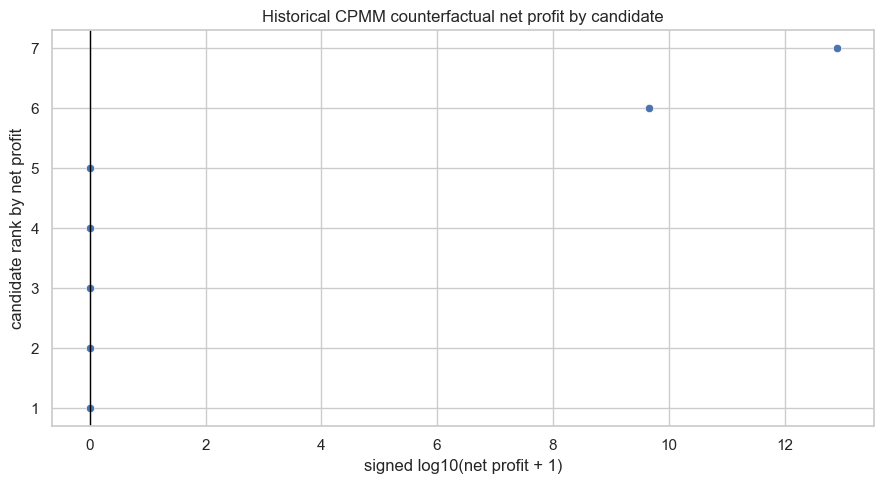

In [6]:
fig = plot_profit_distribution(historical)
if fig is None:
    display(Markdown("Profit distribution plot omitted because candidate profit data is missing, flat, or single-point."))


## Size vs profit


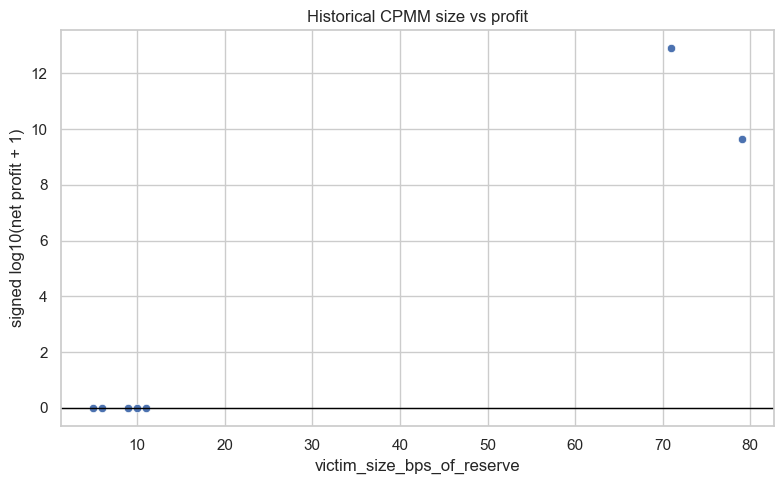

In [7]:
fig = plot_size_vs_profit(historical)
if fig is None:
    display(Markdown("Size-vs-profit plot omitted because candidate size/profit data is missing, flat, or single-point."))


## Slippage feasibility


,metric,value
0,rows with slippage data,7
1,slippage-feasible rate,100.0%
2,median tolerance margin bps,10000.0
3,min tolerance margin bps,2512


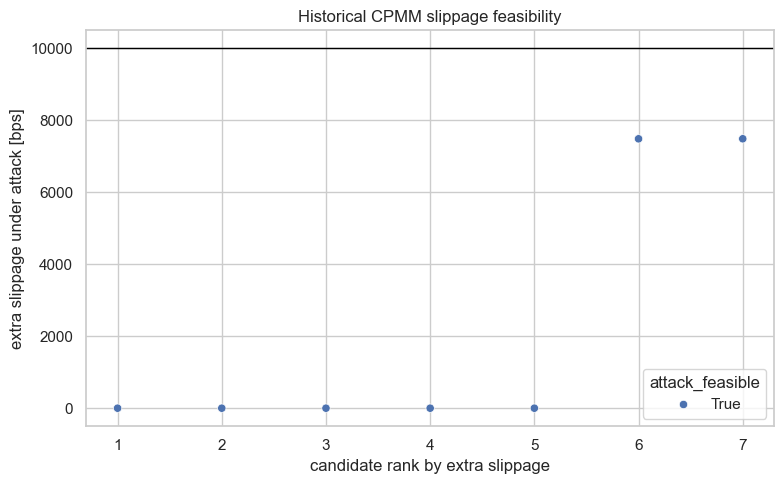

In [8]:
slippage_summary = historical_slippage_summary(historical)
if slippage_summary.empty:
    display(Markdown("No historical CPMM slippage feasibility columns available yet."))
else:
    display(slippage_summary)
fig = plot_slippage_feasibility(historical)
if fig is None:
    display(Markdown("Slippage feasibility plot omitted because the data is missing, flat, or single-point."))


## Top-N candidates


In [9]:
top_candidates = historical_top_candidates(historical, limit=10)
if top_candidates.empty:
    display(Markdown("No ranked historical CPMM candidates yet."))
else:
    display(top_candidates)


,signature,slot,pool_label,victim_amount,amount_in,frontrun_amount,victim_slippage_tolerance_bps,victim_extra_slippage_bps,attacker_net_profit
30,nTBVqrR6x28Wg6q1SsR9o42EjVPvFdosJ9Z1KDcHi6G7P2...,418627325,wsol_surge,20000000000000,20000000000000,2806717723185757,10000,7488,7945785693892
64,4grDjEtXddTsUMyrYNTKNiTCxx7K35uWVrCDhEPZwvAzUx...,418627325,wsol_surge,10715319973,10715319973,1351205792225,10000,7487,4639441864
5,67rH9Hn7rRJVmVJNUtQeRkjwREqSRZ3jQ57Hv179moZno7...,418630501,wsol_debt,152009292,152009292,0,10000,0,0
9,ySXbbeBX9EZcujamW6Bm1z2hRNCPAmu5w9cKWvs8eCfW16...,418628945,wsol_surge,1903251000000,1903251000000,0,10000,0,0
29,38H57hrwmsr8u4ujLX78v4TJZX7ZHZEt1skpVsmdrmmpfe...,418630724,wsol_debt,196983336,196983336,0,10000,0,0
55,3TiJFAGTY8ATuYTgxqK81wgNS6azVWVBVNaohWNZCDY9Sz...,418628471,wsol_debt,107817264032,107817264032,0,10000,0,0
71,3oVSh1M6gNiRTAmTqupwQpCU1A5s22dkvKwGy8ciyJenY6...,418631239,wsol_useless,9338033468,9338033468,0,10000,0,0


## Thesis-ready takeaways


In [10]:
lines = historical_takeaway_lines(comparison, historical, funnel, rejections)
display(Markdown("\n".join(lines) if lines else "No CPMM conclusions yet."))


- Snapshot-derived CPMM realized rate: `25.0%` over `32` rows.
- Historical CPMM evaluated `72` row(s); `7` passed the analysis threshold.
- Main historical rejection reason: `no_cpmm_swap` (`100.0%` of rejected rows).
- Historical CPMM analysis candidates: `7` rows, median net profit `0`.